# Function Transformation

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

In [5]:
# upload the titanic dataset from library

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv', usecols=['Survived', 'Age', 'Fare'])
df.head()





,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [7]:
# impute the missing values in Age colu[mn with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\Muhammad Asim\AppData\Local\Temp\ipykernel_16004\2297338726.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [8]:
x = df.iloc[:, 1:3]
y = df.iloc[:, 0]
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

C:\Users\Muhammad Asim\AppData\Local\Temp\ipykernel_16004\566557295.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'], bins=20)


Text(0.5, 1.0, 'Age Distribution After Transformation by QQ Plot')

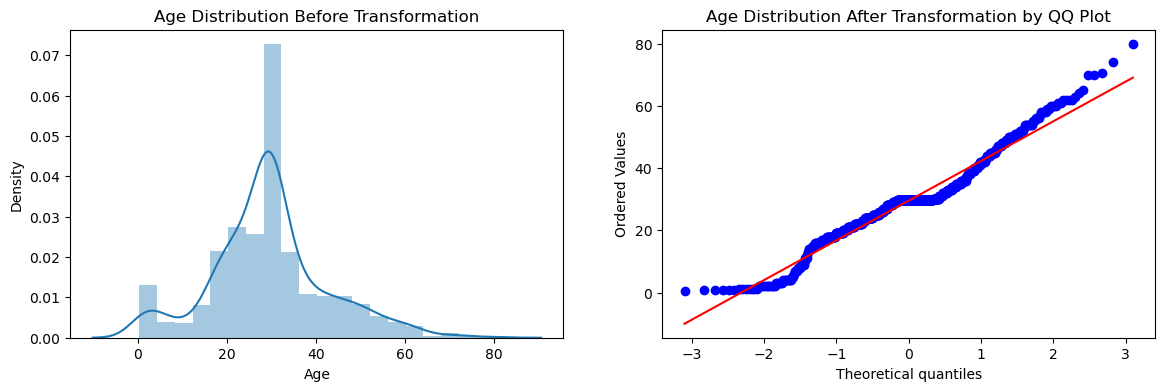

In [10]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(x_train['Age'], bins=20)
plt.title('Age Distribution Before Transformation')
plt.subplot(122)
stats.probplot(x_train['Age'], dist='norm', plot=plt)
plt.title('Age Distribution After Transformation by QQ Plot')


C:\Users\Muhammad Asim\AppData\Local\Temp\ipykernel_16004\1093667363.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'], bins=20)


Text(0.5, 1.0, 'Fare Distribution After Transformation by QQ Plot')

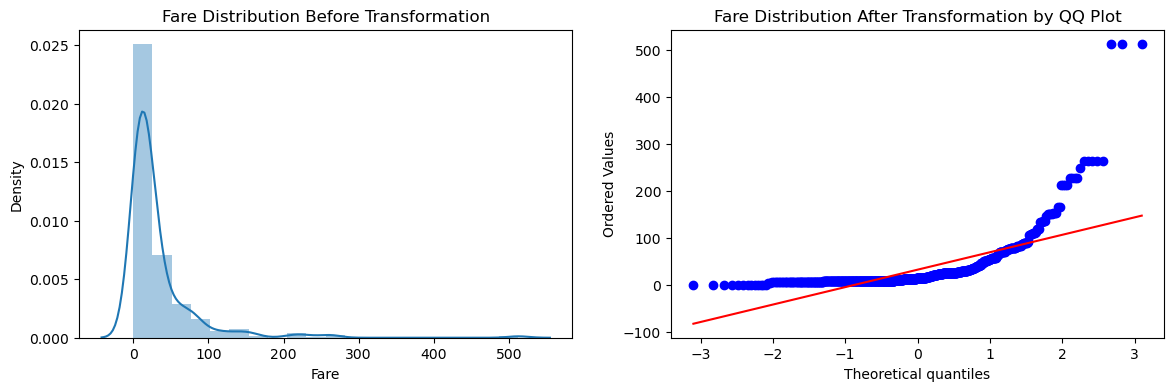

In [12]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(x_train['Fare'], bins=20)
plt.title('Fare Distribution Before Transformation')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Distribution After Transformation by QQ Plot')


KeyError: 'Survived'

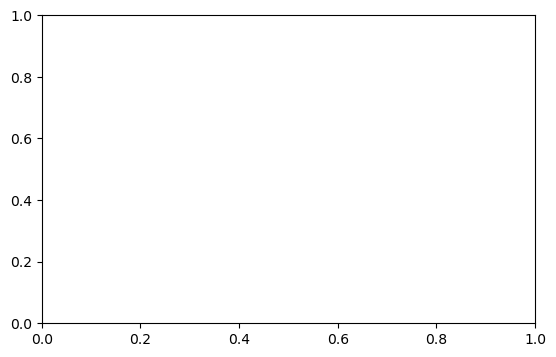

In [18]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(y_train['Survived'], bins=20)
plt.title('Survived Distribution Before Transformation')

plt.subplot(122)
stats.probplot(y_train['Survived'], dist='norm', plot=plt)
plt.title('Survived Distribution After Transformation by QQ Plot')


In [19]:
clf = DecisionTreeClassifier(random_state=42)
clf1 = LogisticRegression(random_state=42)

y_pred = clf.fit(x_train, y_train).predict(x_test)
y_pred1 = clf1.fit(x_train, y_train).predict(x_test)

print('Accuracy of Decision Tree Classifier: ', accuracy_score(y_test, y_pred))
print('Accuracy of Logistic Regression: ', accuracy_score(y_test, y_pred1))

Accuracy of Decision Tree Classifier:  0.659217877094972
Accuracy of Logistic Regression:  0.6480446927374302


In [22]:
trf = FunctionTransformer(np.log1p)
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [24]:
clf = LogisticRegression(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)

clf.fit(x_train_transformed, y_train)
clf2.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print('Accuracy of Decision Tree Classifier: ', accuracy_score(y_test, y_pred))
print('Accuracy of Logistic Regression: ', accuracy_score(y_test, y_pred2))

Accuracy of Decision Tree Classifier:  0.6815642458100558
Accuracy of Logistic Regression:  0.664804469273743


In [26]:
X_tranformed = trf.fit_transform(x)

clf = LogisticRegression(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
print('Cross Validation Score of Decision Tree Classifier: ', cross_val_score(clf2, X_tranformed, y, cv=5).mean())
print('Cross Validation Score of Logistic Regression: ', cross_val_score(clf, X_tranformed, y, cv=5).mean())


Cross Validation Score of Decision Tree Classifier:  0.6430983616847656
Cross Validation Score of Logistic Regression:  0.6780114242671521


C:\Users\Muhammad Asim\AppData\Local\Temp\ipykernel_16004\1427821647.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'], bins=20)


Text(0.5, 1.0, 'Fare Distribution After Transformation by QQ Plot')

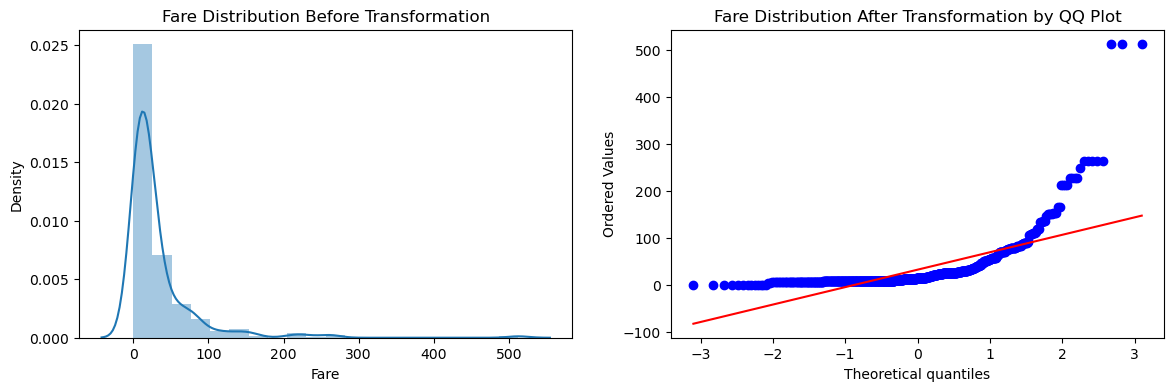

In [30]:
# now print before fare transformation and after fare transformation by plot by qq plot and after

plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.distplot(x_train['Fare'], bins=20)
plt.title('Fare Distribution Before Transformation')


plt.subplot(122)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Distribution After Transformation by QQ Plot')